In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Stage 1: Data Understanding
# In this section, we explore the dataset structure, understand available features, and examine basic statistics.

In [3]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.shape

(250000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [6]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [7]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [8]:
# Stage 2: Data Cleaning
# Raw datasets often contain missing values, duplicate records, or incorrect formats. Data cleaning ensures the dataset is accurate and ready for analysis.

In [9]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [13]:
# Stage 3: Feature Engineering
# Feature engineering creates new useful columns from existing data to uncover hidden patterns and improve analysis.

In [14]:
df['Year'] = df['Purchase Date'].dt.year

In [15]:
df['Month'] = df['Purchase Date'].dt.month

In [16]:
customer_spending = df.groupby('Customer ID')['Total Purchase Amount'].sum()
customer_spending.head()

Customer ID
1     3491
2     7988
3    22587
4     8715
5    12524
Name: Total Purchase Amount, dtype: int64

In [17]:
purchase_frequency = df.groupby('Customer ID').size()
purchase_frequency.head()

Customer ID
1    1
2    3
3    8
4    4
5    8
dtype: int64

In [18]:
# Stage 4: Customer Segmentation
# Customer segmentation divides customers into groups based on spending behavior. This helps businesses target customers with personalized strategies.

In [19]:
df['Segment'] = pd.qcut(
    df['Total Purchase Amount'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

In [20]:
df['Segment'].value_counts()

Segment
Low Value       83344
Medium Value    83332
High Value      83324
Name: count, dtype: int64

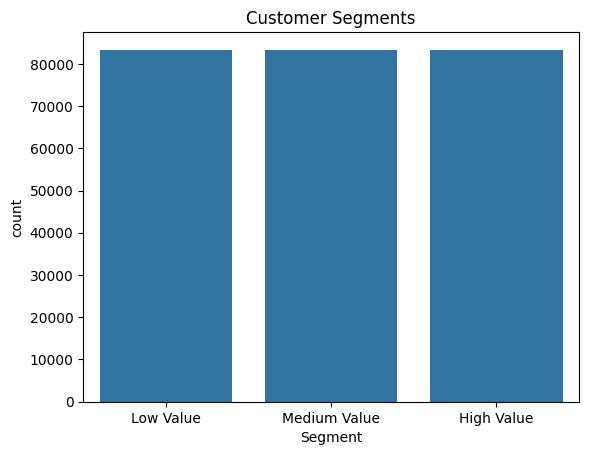

In [21]:
sns.countplot(x='Segment', data=df)
plt.title("Customer Segments")
plt.show()

In [22]:
df.groupby('Segment', observed=False)['Total Purchase Amount'].mean()

Segment
Low Value       1060.259347
Medium Value    2725.245788
High Value      4391.006745
Name: Total Purchase Amount, dtype: float64

In [23]:
# Stage 5: Purchase Pattern Analysis
# We analyze buying behavior to identify popular products, preferred payment methods, and customer demographics.

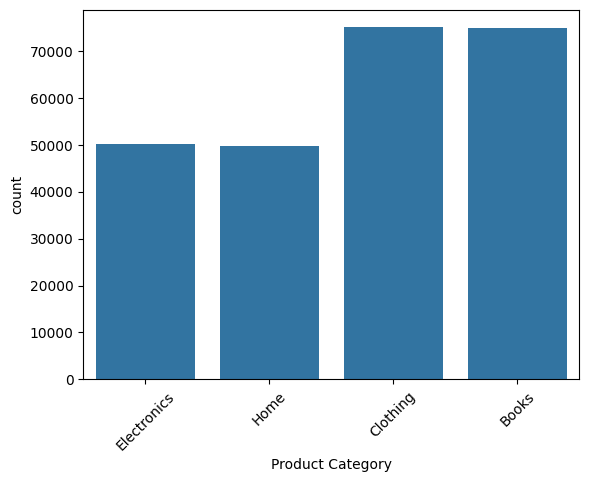

In [24]:
sns.countplot(x='Product Category', data=df)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Product Category'>

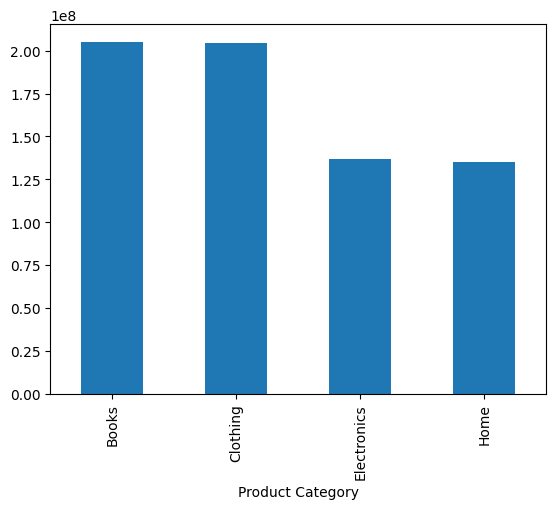

In [25]:
df.groupby('Product Category')['Total Purchase Amount'].sum().plot(kind='bar')

<Axes: ylabel='count'>

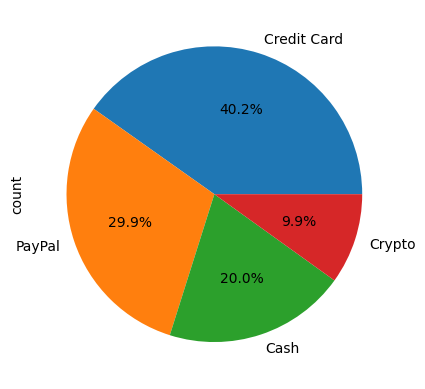

In [26]:
df['Payment Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

<Axes: xlabel='Age', ylabel='Count'>

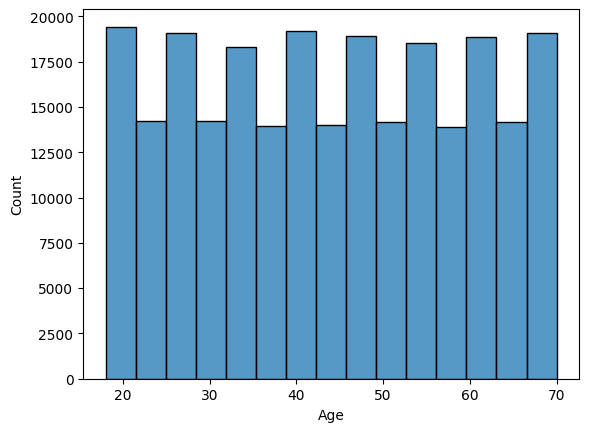

In [27]:
sns.histplot(df['Age'], bins=15)

In [28]:
# Stage 6: Churn Analysis
# Churn analysis helps identify customers who stop purchasing and highlights factors contributing to customer loss.

<Axes: xlabel='Churn', ylabel='count'>

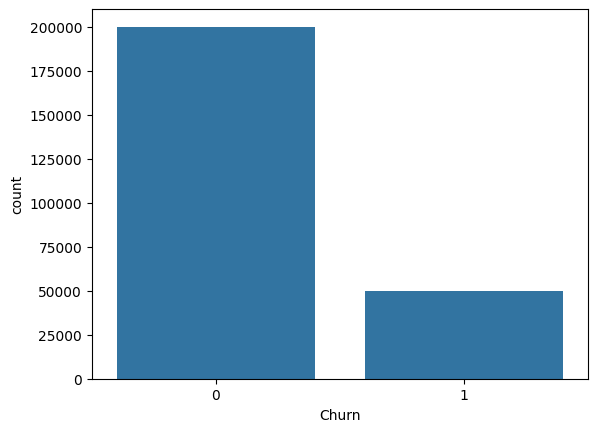

In [29]:
sns.countplot(x='Churn', data=df)

<Axes: xlabel='Gender', ylabel='count'>

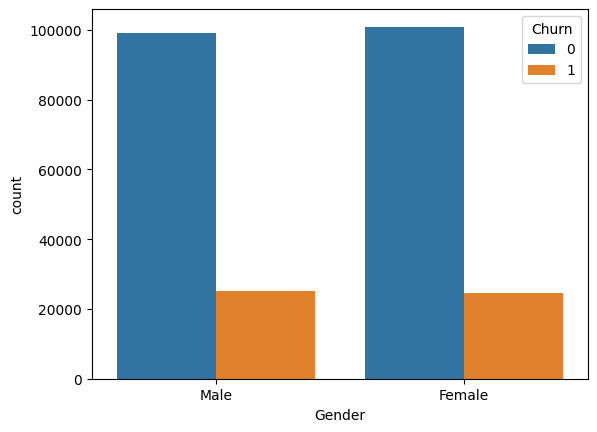

In [30]:
sns.countplot(
    x='Gender',
    hue='Churn',
    data=df
)

<Axes: xlabel='Product Category'>

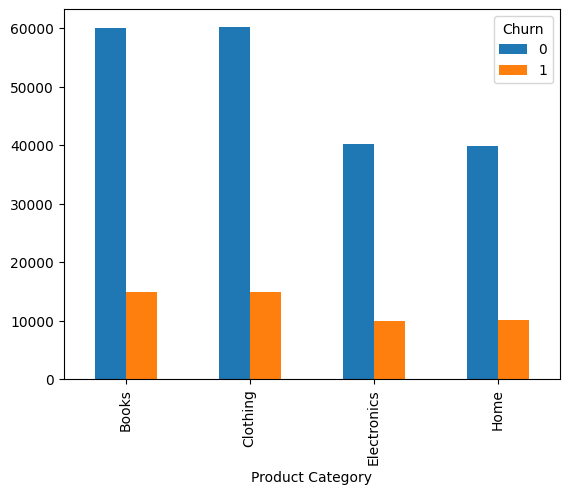

In [31]:
pd.crosstab(
    df['Product Category'],
    df['Churn']
).plot(kind='bar')

In [32]:
churn_rate = (df['Churn'].sum()/len(df))*100
print(churn_rate)

19.9496


In [33]:
# Stage 7: Retention Trend Analysis
# Retention analysis helps determine which customer groups are more likely to stay with the business.

<Axes: xlabel='Segment', ylabel='count'>

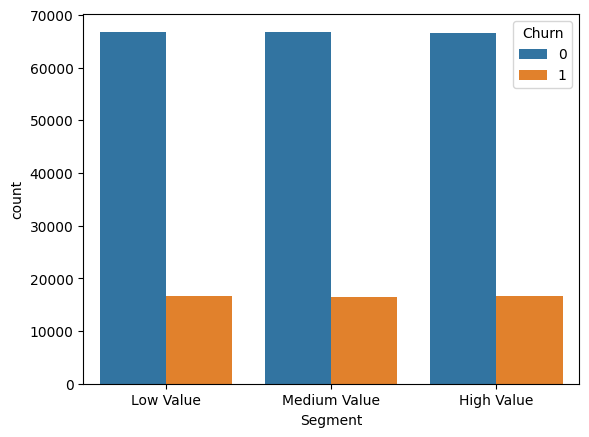

In [34]:
sns.countplot(
    x='Segment',
    hue='Churn',
    data=df
)

In [35]:
# Recommendations

# 1. Introduce loyalty rewards for high-value customers.
# 2. Provide targeted discounts to low-value customers.
# 3. Launch churn-prevention campaigns for at-risk customers.
# 4. Promote top-performing product categories.
# 5. Improve product descriptions to reduce returns.